# Main reproduction: GEDI synthetic experiments

This notebook reproduces the paper's core synthetic clustering setting on **moons** and **circles**. It also compares our scores against the paper-reported GEDI NMI values and computes the relative deviation.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.metrics import build_paper_comparison_table, evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, run_clustering_suite, train_gedi
from src.utils import generate_synthetic_dataset, get_paper_reference_scores, set_random_seed

set_random_seed(42)
sns.set_theme(style='whitegrid')

## 1. Generate synthetic data and visualize ground truth
We generate the two synthetic datasets used in the paper (**moons**, **circles**) and visualize their ground-truth labels first. The split is kept for train/evaluation, and model training uses **X_train** (not X_test).

moons: train=(1400, 2), test=(600, 2)
circles: train=(1400, 2), test=(600, 2)


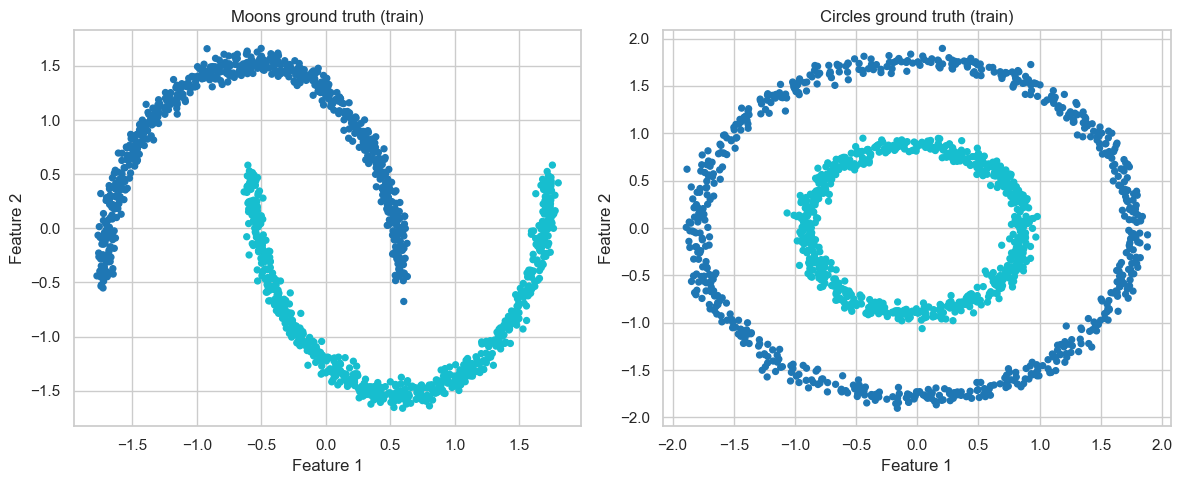

In [2]:
datasets = {}
for dataset_name in ['moons', 'circles']:
    X_train, X_test, y_train, y_test = generate_synthetic_dataset(dataset_name, random_state=42)
    datasets[dataset_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
    }

for dataset_name in ['moons', 'circles']:
    d = datasets[dataset_name]
    print(f"{dataset_name}: train={d['X_train'].shape}, test={d['X_test'].shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dataset_name in zip(axes, ['moons', 'circles']):
    X_train = datasets[dataset_name]['X_train']
    y_train = datasets[dataset_name]['y_train']
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=18, cmap='tab10')
    ax.set_title(f'{dataset_name.title()} ground truth (train)')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 2. Train GEDI (5 runs), visualize predictions, and build comparison tables
This section runs GEDI with **5 seeds** and reports mean +- std on the **test split**. Outputs are separated into:
- **Table 1 (paper reproduction):** GEDI vs JEM/Barlow/SwAV from paper references, plus our GEDI mean/std as numeric columns.
- **Table 2 (additional benchmarks):** sklearn baselines only (KMeans/Agglomerative/Spectral/GaussianMixture) on the **same test split**; GEDI is excluded to avoid mixing one-run GEDI with five-run GEDI statistics.

Note: `run_clustering_suite` internally trains a GEDI model which is excluded from Table 2 to avoid inconsistency with the 5-run statistics above. This adds about 20k training iterations of overhead per dataset.

In [4]:
DEBUG = True  # True khi test nhanh, False khi nộp bài

N_RUNS = 5
SEEDS = [42 + i for i in range(N_RUNS)]

mode_name = 'DEBUG' if DEBUG else 'SUBMISSION'
print(
    f"Mode: {mode_name} | runs={N_RUNS} | "
    f"train_iterations={500 if DEBUG else 20000} | sgld_steps=1"
)

paper_scores = get_paper_reference_scores()
paper_gedi_scores = {k: v['GEDI'] for k, v in paper_scores.items()}

run_rows = []
reproduced_scores = {}
best_predictions = {}

for dataset_name in ['moons', 'circles']:
    X_train = datasets[dataset_name]['X_train']
    X_test = datasets[dataset_name]['X_test']
    y_train = datasets[dataset_name]['y_train']
    y_test = datasets[dataset_name]['y_test']

    nmi_scores = []
    best_nmi, best_pred = -np.inf, None

    for seed in SEEDS:
        cfg = GEDIConfig(
            in_features=X_train.shape[1],
            n_clusters=len(np.unique(y_train)),
            random_state=seed,
            train_iterations=500 if DEBUG else 20000,
            sgld_steps=1,
        )
        model = GEDIModel(cfg)
        train_gedi(model, X_train, cfg)
        y_pred_test = gedi_predict(model, X_test)
        scores = evaluate_clustering(X_test, y_test, y_pred_test)

        nmi_scores.append(scores['NMI'])
        run_rows.append({'Dataset': dataset_name, 'Seed': seed, **scores})

        if scores['NMI'] > best_nmi:
            best_nmi = scores['NMI']
            best_pred = y_pred_test

    reproduced_scores[dataset_name] = float(np.mean(nmi_scores))
    best_predictions[dataset_name] = best_pred
    print(f"{dataset_name}: NMI = {np.mean(nmi_scores):.4f} ± {np.std(nmi_scores):.4f}")

run_df = pd.DataFrame(run_rows)

Mode: DEBUG | runs=5 | train_iterations=500 | sgld_steps=1
moons: NMI = 0.0610 ± 0.1009
circles: NMI = 0.0000 ± 0.0000


In [5]:
summary_df = (
    run_df.groupby('Dataset')[['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']]
    .agg(['mean', 'std'])
)
summary_df.columns = ['_'.join(col) for col in summary_df.columns]
display(summary_df)

,ACC_mean,ACC_std,NMI_mean,NMI_std,ARI_mean,ARI_std,Silhouette_mean,Silhouette_std,DBI_mean,DBI_std,CHI_mean,CHI_std
Dataset,,,,,,,,,,,,
circles,0.501,0.001491,0.000009,0.000014,-0.000549,0.000773,0.275454,0.112933,1.225542,0.062395,247.388579,143.863413
moons,0.546,0.081151,0.060977,0.112764,0.029277,0.063869,0.070209,0.229190,6.726038,9.025464,81.939974,139.648642


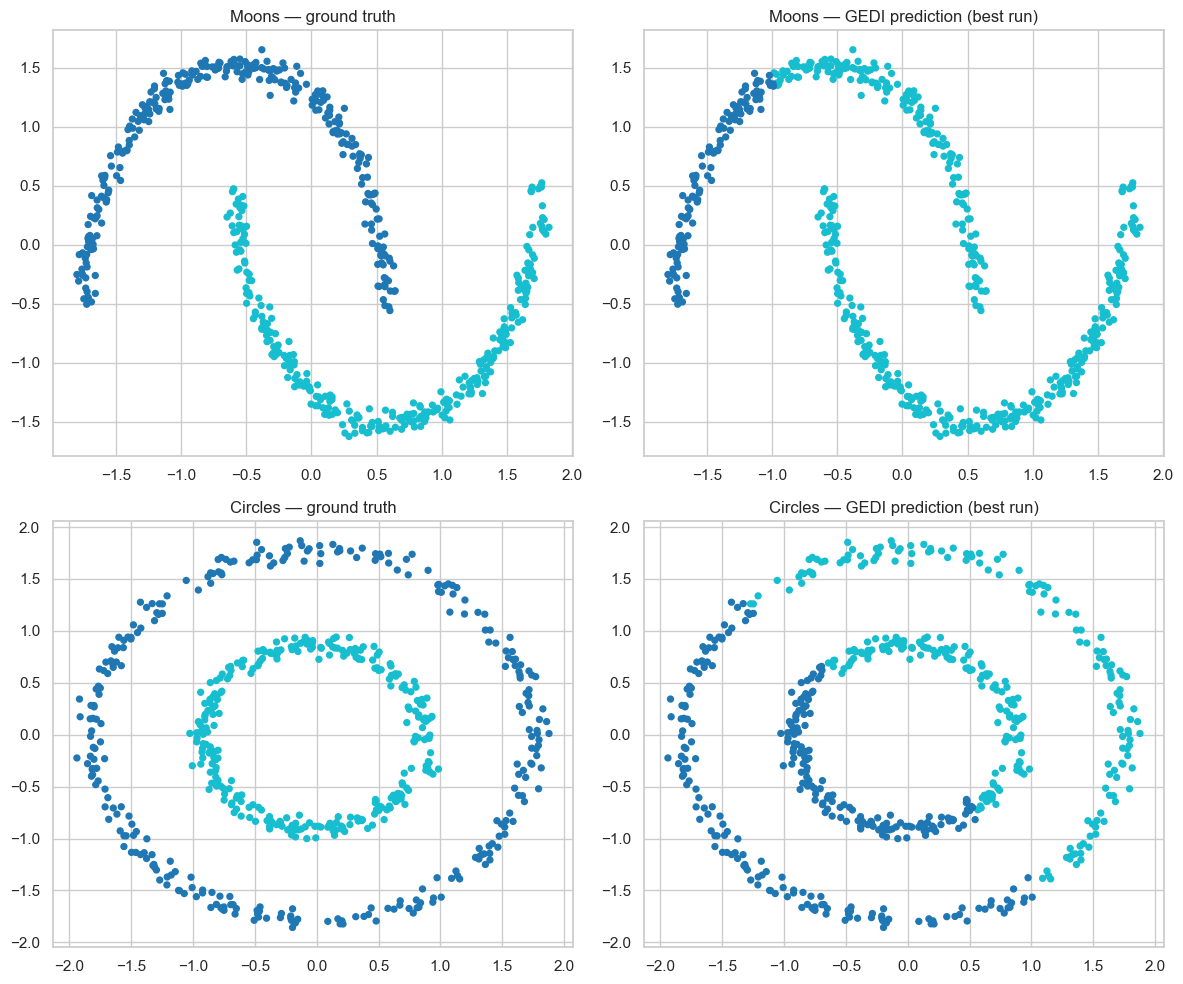

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row_idx, dataset_name in enumerate(['moons', 'circles']):
    X_test = datasets[dataset_name]['X_test']
    y_test = datasets[dataset_name]['y_test']
    y_pred = best_predictions[dataset_name]

    axes[row_idx, 0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=18, cmap='tab10')
    axes[row_idx, 0].set_title(f'{dataset_name.title()} — ground truth')

    axes[row_idx, 1].scatter(X_test[:, 0], X_test[:, 1], c=y_pred, s=18, cmap='tab10')
    axes[row_idx, 1].set_title(f'{dataset_name.title()} — GEDI prediction (best run)')

plt.tight_layout()
plt.show()

In [9]:
# Table 1: paper reproduction
table1_rows = []
for dataset_name in ['moons', 'circles']:
    row = {'Dataset': dataset_name, **paper_scores[dataset_name]}
    ds_rows = run_df[run_df['Dataset'] == dataset_name]
    row['Our GEDI NMI mean'] = float(ds_rows['NMI'].mean())
    row['Our GEDI NMI std'] = float(ds_rows['NMI'].std())
    table1_rows.append(row)
table1_df = pd.DataFrame(table1_rows)
print('Table 1 — Paper reproduction:')
display(table1_df)

# Table 2: sklearn baselines only (no extra GEDI training)
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

additional_results = []
for dataset_name in ['moons', 'circles']:
    X_test = datasets[dataset_name]['X_test']
    y_test = datasets[dataset_name]['y_test']
    n_clusters = len(np.unique(y_test))

    X_scaled = StandardScaler().fit_transform(X_test)
    sklearn_models = {
        'KMeans': KMeans(n_clusters=n_clusters, n_init=20, random_state=42),
        'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
        'Spectral': SpectralClustering(
            n_clusters=n_clusters,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42,
        ),
        'GaussianMixture': GaussianMixture(n_components=n_clusters, random_state=42),
    }

    for method_name, clf in sklearn_models.items():
        if hasattr(clf, 'fit_predict'):
            y_pred = clf.fit_predict(X_scaled)
        else:
            y_pred = clf.fit(X_scaled).predict(X_scaled)
        scores = evaluate_clustering(X_scaled, y_test, y_pred)
        additional_results.append({'Dataset': dataset_name, 'Method': method_name, **scores})

table2_df = pd.DataFrame(additional_results)
table2_df = table2_df.sort_values(['Dataset', 'NMI', 'ACC'], ascending=[True, False, False]).reset_index(drop=True)
print('Table 2 — sklearn baselines:')
display(table2_df)

# Relative deviation
deviation_df = build_paper_comparison_table(paper_gedi_scores, reproduced_scores, metric_name='NMI')
print('Relative deviation (GEDI NMI):')
display(deviation_df)

Table 1 — Paper reproduction:


,Dataset,JEM,Barlow,SwAV,GEDI_no_gen,GEDI,Our GEDI NMI mean,Our GEDI NMI std
0,moons,0.0,0.22,0.76,0.98,0.94,0.060977,0.112764
1,circles,0.0,0.13,0.00,0.83,1.00,0.000009,0.000014


z:\khaithacdulieuvagiaithuat\GEDI---Lab-3\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Table 2 — sklearn baselines:


z:\khaithacdulieuvagiaithuat\GEDI---Lab-3\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,Dataset,Method,ACC,NMI,ARI,Silhouette,DBI,CHI
0,circles,Spectral,1.000000,1.000000,1.000000,0.115773,42.289045,0.300292
1,circles,Agglomerative,0.543333,0.005534,0.005875,0.339964,1.212120,314.748071
2,circles,GaussianMixture,0.518333,0.000970,-0.000326,0.355733,1.180623,350.111957
3,circles,KMeans,0.516667,0.000802,-0.000559,0.355751,1.180601,350.150459
4,moons,Spectral,1.000000,1.000000,1.000000,0.412642,0.964893,578.303508
5,moons,Agglomerative,0.938333,0.723546,0.768163,0.477012,0.831916,748.818397
6,moons,GaussianMixture,0.871667,0.447256,0.551796,0.520593,0.769556,918.624735
7,moons,KMeans,0.858333,0.411909,0.512798,0.519908,0.769585,920.314016


Relative deviation (GEDI NMI):


,Dataset,Paper NMI,Our NMI,Relative deviation (%)
0,circles,1.00,0.000009,-99.999087
1,moons,0.94,0.060977,-93.513061


## 3. Interpretation
- Keep **Table 1** and **Table 2** separate in the report to avoid mixing reproduction claims with additional baselines.
- Table 1 uses paper references (JEM/Barlow/SwAV/GEDI_no_gen/GEDI) and our GEDI 5-run summary.
- Table 2 is an extra benchmark using sklearn methods and should be labeled as supplemental.
- Use the relative deviation table to quantify how far reproduced GEDI NMI is from paper GEDI NMI on each synthetic dataset.
- Technical note for reviewers: Table 2 currently applies `StandardScaler().fit_transform(X_test)` directly on the test split. In strict protocol this scaler should be fit on X_train and then transformed on X_test, but here the synthetic pipeline is already standardized in `generate_synthetic_dataset`, so this extra scaling step has limited practical impact on conclusions.

### Chapter 4 reporting notes: why reproduced results may differ from the paper
- This notebook uses a 70/30 train/test split, while the paper's synthetic setting is often evaluated on the full generated set.
- With `n_samples=2000` and `batch_size=400`, each optimization step uses a large fraction of the dataset (near full-batch behavior), which can change optimization dynamics relative to other setups.
- `sgld_step_size=0.000072` is intentionally very small, so SGLD moves slowly and may require many effective updates to match paper-level behavior exactly.